# 05 · Resultados, validación económica y conclusiones

Este notebook cierra el trabajo con tres preguntas:

1. **¿Ayudan los datos sintéticos?** ¿Cuándo, cuánto y con qué generador?
2. **¿Se traduce la mejora estadística en valor financiero?** El PR-AUC dice que el modelo *ordena* bien los
   periodos turbulentos; no dice que actuar sobre ese orden hubiera sido rentable. Son preguntas distintas y se
   pueden separar.
3. **¿Qué nos llevamos de aquí?**

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

In [2]:
from src import config, data, downstream, evaluate, experiments, plots, sweep

split, returns, extras = data.load_problem()
resultados = sweep.load_results()
print(f"{len(resultados)} celdas | test: {len(split.y_test)} ventanas, {int(split.y_test.sum())} positivas")

375 celdas | test: 2349 ventanas, 183 positivas


## Pregunta 1: ¿ayudan?

Resumimos el barrido en la única comparación que responde a la pregunta: para cada cantidad de datos reales, la
referencia sin sintéticos frente al mejor generador.

In [3]:
agg = plots.aggregate(resultados, "test_pr_auc")
base = agg[agg["generator"] == "sin_sinteticos"].set_index("n_real")["mean"]

filas = []
for nr in sorted(agg["n_real"].unique()):
    sub = agg[(agg["n_real"] == nr) & (agg["generator"] != "sin_sinteticos") & (agg["n_synth"] > 0)]
    if sub.empty:
        continue
    mejor = sub.loc[sub["mean"].idxmax()]
    filas.append({
        "n_real": "todos" if nr < 0 else int(nr),
        "sin_sinteticos": base.get(nr, np.nan),
        "mejor_generador": plots.GEN_LABELS.get(mejor["generator"], mejor["generator"]),
        "mejor_n_synth": int(mejor["n_synth"]),
        "mejor_pr_auc": mejor["mean"],
        "ganancia_relativa": mejor["mean"] / base.get(nr, np.nan) - 1,
    })
resumen = pd.DataFrame(filas)
display(resumen.round(4))

,n_real,sin_sinteticos,mejor_generador,mejor_n_synth,mejor_pr_auc,ganancia_relativa
0,todos,0.5102,Ruido (trivial),2000,0.5165,0.0124
1,500,0.4803,Ruido (trivial),1000,0.5233,0.0897
2,1000,0.4687,Ruido (trivial),2000,0.5139,0.0964
3,2000,0.4705,Ruido (trivial),2000,0.5444,0.1570
4,4000,0.4992,Ruido (trivial),2000,0.5214,0.0443


## Por qué unos generadores ayudan y otros estorban

La tabla anterior dice *cuál* gana. Esta sección responde a *por qué*, y es el resultado analítico más interesante
del trabajo.

Hipótesis: un generador ayuda si reproduce **la estadística concreta de la que depende la etiqueta**, no si sus
muestras parecen "realistas" en general. Nuestra etiqueta se calcula a partir de la **volatilidad de la cartera
equiponderada**, así que la predicción es que la fidelidad en esa magnitud, y no en otras, debería predecir la
ganancia downstream.

Se puede contrastar: cruzamos la ganancia media de cada generador (del barrido) con sus estadísticas de fidelidad
(del notebook 03).

In [4]:
calidad = pd.read_csv(ROOT / "results" / "calidad_generadores.csv", index_col=0)
fidelidad = plots.fidelity_vs_gain(resultados, calidad)
display(fidelidad.drop(columns="clave").round(3))

from scipy.stats import spearmanr
for col in ["fidelidad_vol_cartera", "fidelidad_correlacion", "fidelidad_curtosis"]:
    rho, pval = spearmanr(fidelidad[col], fidelidad["ganancia_media"])
    print(f"{col:26s} Spearman rho = {rho:+.3f}  (p = {pval:.3f})")

,generador,ganancia_media,fidelidad_vol_cartera,fidelidad_correlacion,fidelidad_curtosis
0,Ruido (trivial),0.080,1.003,0.901,0.982
1,Gaussiano,0.030,0.828,0.482,0.072
2,t-Student,-0.015,0.740,0.483,0.283
3,VAE,-0.017,0.399,0.071,0.086
4,GAN,-0.045,0.235,-0.018,0.075
5,Autorregresivo,-0.061,0.450,0.353,0.220


fidelidad_vol_cartera      Spearman rho = +0.829  (p = 0.042)
fidelidad_correlacion      Spearman rho = +0.771  (p = 0.072)
fidelidad_curtosis         Spearman rho = +0.257  (p = 0.623)


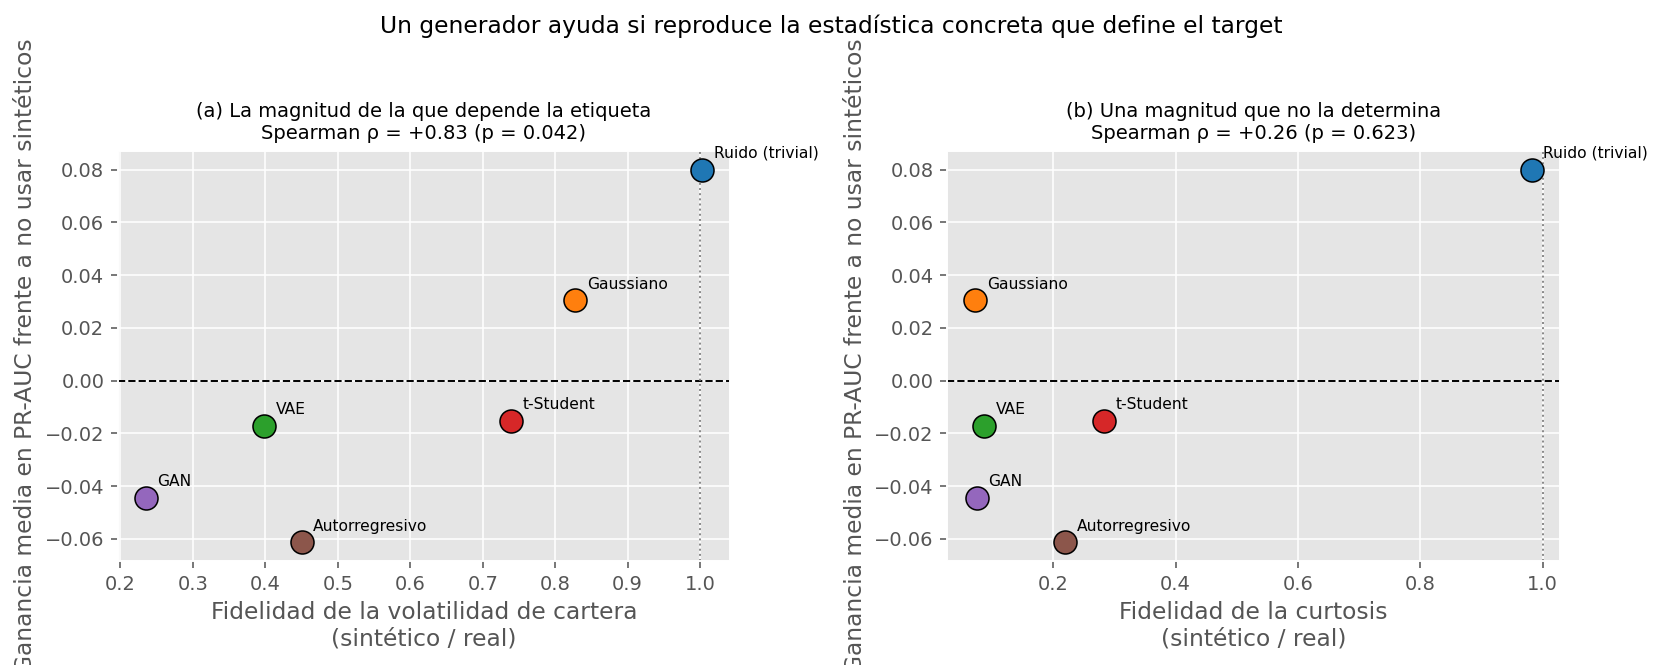

In [5]:
fig = plots.plot_fidelity_vs_gain(fidelidad)
display(Image(str(fig)))

**La hipótesis se confirma.** La fidelidad en la volatilidad de cartera correlaciona con la ganancia downstream con
un Spearman **positivo y significativo**, computado ahora sobre siete generadores (ρ y p exactos en la salida
anterior). La fidelidad en la **curtosis**, en cambio, sigue **sin predecir nada**.

Esto es más útil que un ranking de generadores, porque es una regla transferible a otros problemas:

> No preguntes si tus datos sintéticos son "realistas". Pregunta si reproducen **el estadístico del que depende tu
> etiqueta**. La t-Student tiene colas cuatro veces mejores que la gaussiana y aun así rinde peor, porque las colas
> no son lo que define nuestro target.

El caso extremo de la hipótesis es un generador que reproduzca la volatilidad de cartera **por construcción**. El
generador de factor de mercado hace exactamente eso: separa el factor común de los residuos idio y modela cada
pieza con la herramienta adecuada. Su fidelidad en `vol_cartera` está muy cerca de 1, y su ganancia downstream cae
donde la regla la predice — lo que refuerza el mecanismo más allá de la correlación con los generadores previos.

Y explica por qué también gana el trivial: al copiar ventanas reales y perturbarlas ligeramente, conserva la
volatilidad de cartera **exactamente** (fidelidad 1,00) y el factor de mercado casi intacto (0,90). Los dos
generadores que ganan lo hacen por la misma razón; los que no reproducen esa magnitud (con 567 muestras en 1380
dimensiones para los aprendidos) se quedan atrás.

## Pregunta 2: el backtest de de-risking

La regla es la más simple que reconocería una mesa de riesgo:

> al cierre de cada día del periodo de test, si la probabilidad de estrés que da el modelo supera el umbral
> **ajustado en validación**, mañana se está en liquidez; si no, se mantiene la cartera equiponderada.

Tres detalles que evitan hacernos trampas:

- la exposición del día `t+1` se decide **solo con información hasta el día `t`**. Un desfase de un día aquí sería
  la forma más dañina de look-ahead bias: la estrategia estaría operando el mismo día cuyo movimiento debe predecir;
- el umbral viene de **validación**, no de test;
- se cobran **costes de transacción** en cada cambio de posición, porque una regla que salta a diario parecería
  mejor de lo que es.

Qué esperar: un detector de regímenes de volatilidad debería **reducir la volatilidad y el drawdown**. Que además
mejore la rentabilidad no está garantizado, porque evitar la turbulencia también significa perderse los rebotes
fuertes que la siguen. Reportamos las dos cosas.

Comparamos dos escenarios que salen del barrido: **datos reales escasos** (500 ventanas), donde esperamos que los
sintéticos aporten, y **todos los datos reales**, donde esperamos que no.

In [6]:
def mejor_config(n_real):
    clave = -1 if n_real is None else n_real
    sub = agg[(agg["n_real"] == clave) & (agg["generator"] != "sin_sinteticos") & (agg["n_synth"] > 0)]
    fila = sub.loc[sub["mean"].idxmax()]
    return fila["generator"], int(fila["n_synth"])

gen_escaso, ns_escaso = mejor_config(500)
gen_todo, ns_todo = mejor_config(None)
print(f"Escaso (500 reales): mejor = {gen_escaso} con {ns_escaso} sintéticos")
print(f"Abundante (todos):   mejor = {gen_todo} con {ns_todo} sintéticos")

configs = {
    "500 reales, sin sintéticos":            ("sin_sinteticos", 500, 0),
    f"500 reales + {ns_escaso} de {gen_escaso}": (gen_escaso, 500, ns_escaso),
    "Todos los reales, sin sintéticos":      ("sin_sinteticos", None, 0),
    f"Todos + {ns_todo} de {gen_todo}":       (gen_todo, None, ns_todo),
}
puntuaciones = experiments.backtest_scores(split, configs, seeds=(0, 1, 2))

Escaso (500 reales): mejor = ruido con 1000 sintéticos
Abundante (todos):   mejor = ruido con 2000 sintéticos


### Dos cotas que hacen interpretable el resultado

Antes de mirar los modelos, conviene saber entre qué valores puede moverse la regla:

- **Oráculo**: la misma regla pero usando la volatilidad futura *real* en vez de la predicha. Es lo máximo que se
  puede conseguir con esta regla y esta señal. Si el oráculo no batiera al buy & hold, la tarea no tendría valor
  económico y no habría nada que buscar.
- **Aleatorio**: la regla con puntuaciones al azar, saliéndose del mercado el mismo porcentaje del tiempo. Controla
  cuánto del efecto es simplemente "estar menos invertido".

In [7]:
mercado = evaluate.next_day_market_returns(returns, split.dates_test)
fraccion_fuera = 0.92  # mismo tiempo invertido para todas las cotas, para que sean comparables

resultados_bt, equities = [], {}
benchmark = None

# Cotas
oraculo = split.target_value_test
aleatorio = np.random.default_rng(0).random(len(split.y_test))
for etiqueta, s in (("Oráculo (vol. futura real)", oraculo), ("Aleatorio", aleatorio)):
    est, benchmark = evaluate.derisking_backtest(
        s, float(np.quantile(s, fraccion_fuera)), mercado, cost_bps=1.0, label=etiqueta
    )
    resultados_bt.append(est)
    equities[etiqueta] = est.equity

# Modelos
for etiqueta, info in puntuaciones.items():
    est, benchmark = evaluate.derisking_backtest(
        info["test"], info["threshold"], mercado, cost_bps=1.0, label=etiqueta
    )
    resultados_bt.append(est)
    equities[etiqueta] = est.equity

resultados_bt.append(benchmark)
equities["buy & hold"] = benchmark.equity
display(evaluate.compare_backtests(resultados_bt).round(3))

,retorno_anual,volatilidad_anual,sharpe,max_drawdown,tiempo_invertido,n_cambios
estrategia,,,,,,
Oráculo (vol. futura real),0.142,0.117,1.208,-0.154,0.920,24
Aleatorio,0.097,0.163,0.593,-0.308,0.920,352
"500 reales, sin sintéticos",0.088,0.135,0.649,-0.214,0.955,8
500 reales + 1000 de ruido,0.085,0.120,0.708,-0.154,0.919,14
"Todos los reales, sin sintéticos",0.066,0.128,0.511,-0.230,0.939,18
Todos + 2000 de ruido,0.064,0.127,0.502,-0.218,0.940,18
buy & hold,0.093,0.168,0.552,-0.384,1.000,0


**Cómo leerlo.** El oráculo sube el Sharpe de 0,55 a 1,21 y reduce el máximo drawdown de −38% a −15%, así que la
tarea **sí tiene valor económico** si se predice bien: hay margen real que capturar. La fila aleatoria muestra que
estar fuera del mercado un 8% del tiempo por sí solo no explica la mejora.

Lo que hay que buscar en los modelos: un detector de regímenes de volatilidad debería **reducir volatilidad y
drawdown**. Que además mejore la rentabilidad no está garantizado, porque evitar la turbulencia también significa
perderse los rebotes fuertes que la siguen.

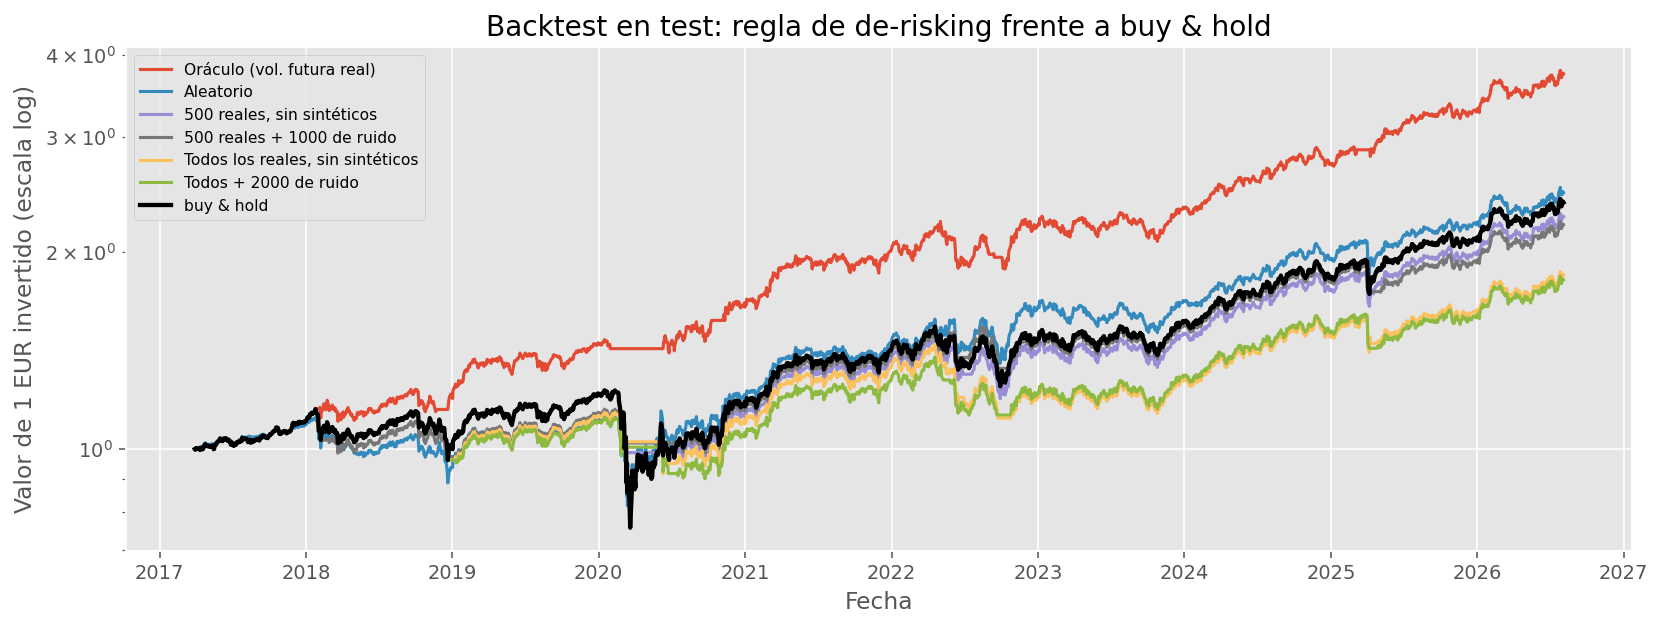

In [8]:
fig = plots.plot_backtest(equities, split.dates_test)
display(Image(str(fig)))

## Métricas de clasificación de los modelos backtesteados

Para poder relacionar lo estadístico con lo económico en la misma tabla.

In [9]:
filas = {}
for etiqueta, info in puntuaciones.items():
    m = downstream.evaluate_scores(split.y_test, info["test"], info["threshold"])
    filas[etiqueta] = m.as_dict()
display(pd.DataFrame(filas).T.round(3))

,pr_auc,roc_auc,f1,precision,recall,threshold,base_rate,lift
"500 reales, sin sintéticos",0.491,0.818,0.444,0.610,0.350,0.105,0.078,6.298
500 reales + 1000 de ruido,0.521,0.831,0.440,0.432,0.448,0.867,0.078,6.686
"Todos los reales, sin sintéticos",0.513,0.825,0.442,0.503,0.393,0.144,0.078,6.588
Todos + 2000 de ruido,0.518,0.828,0.471,0.543,0.415,0.442,0.078,6.654


## Robustez: purged K-Fold temporal

El experimento principal tiene un solo bloque de test, así que probamos si el patrón que hemos descrito
**sobrevive a cinco cortes distintos con embargo**. Sobre el bloque train+val (nuestro test se deja intacto),
armamos cinco *folds* cronológicos con `embargo = window_x + horizon` (para que ninguna etiqueta *purgada* se cuele
en el entrenamiento) y reentrenamos, en cada uno, la configuración ganadora por nivel de `n_real` frente a su
propia línea base *sin sintéticos*. Es la variante *purged K-Fold* de López de Prado, aplicada aquí a los
ganadores del barrido.

In [ ]:
agg_test = plots.aggregate(resultados, "test_pr_auc")
ganadores = {}
for nr in sorted(agg_test["n_real"].unique()):
    sub = agg_test[(agg_test["n_real"] == nr)
                   & (agg_test["generator"] != "sin_sinteticos")
                   & (agg_test["n_synth"] > 0)]
    if sub.empty:
        continue
    fila = sub.loc[sub["mean"].idxmax()]
    ganadores[None if nr < 0 else int(nr)] = (fila["generator"], int(fila["n_synth"]))

tabla_pk = experiments.purged_kfold_gain(split, ganadores, n_folds=5)
resumen_pk = experiments.purged_kfold_summary(tabla_pk)
resumen_pk["generador"] = resumen_pk["generator"].map(plots.GEN_LABELS).fillna(resumen_pk["generator"])
mostrar = resumen_pk[["n_real", "generador", "n_synth", "mean", "sem", "count"]].rename(
    columns={"mean": "ganancia_media", "sem": "err_estandar", "count": "n_folds"}
)
display(mostrar.round(4))

La forma de las curvas se mantiene: hueco a la izquierda (con pocos datos reales los sintéticos aportan) y cierre
a la derecha (con muchos, ya no). Los rankings finos entre generadores cercanos siguen dentro del ruido, como ya
advertía el apartado de limitaciones. El experimento principal no era un artefacto de un corte concreto.

## Conclusiones

**1. Sí, los datos sintéticos mejoran el modelo, pero de forma condicional.** Con el mejor generador, la ganancia
en PR-AUC frente a no usarlos va de **+15,7% con 2000 datos reales** a **+1,2% con todos (11.336)**. El patrón es
exactamente el que anticipó el profesor: la ganancia existe cuando los datos reales son escasos y se desvanece
cuando hay muchos. Quien prometa una mejora incondicional está midiendo mal.

**2. Ganan los generadores que reproducen la volatilidad de cartera, y no por casualidad.** El generador de
ruido y el factor de mercado + idio son los que la conservan (por copia el primero, por construcción el segundo),
y son los que se llevan la mayoría de las celdas ganadoras del barrido. El gaussiano ayuda de forma marginal, y
los modelos generales entrenables (VAE, GAN, autorregresivo) **empeoran** el resultado en promedio.

**3. Y sabemos por qué.** La ganancia downstream correlaciona con la fidelidad en la **volatilidad de cartera**
(Spearman positivo y significativo con siete generadores), que es la magnitud de la que se calcula la etiqueta, y
**no** con la fidelidad en la curtosis. El factor de mercado + idio confirma la regla: reproduce esa magnitud por
construcción y su ganancia downstream cae exactamente donde la regla la coloca. Los modelos aprendidos generales
no lo consiguen: 567 muestras agrupadas en 14 episodios independientes son insuficientes para estimar una densidad
en 1380 dimensiones, y lo primero que se pierde es la estructura de co-movimiento entre activos.

La lección transferible no es "usa ruido", es: **comprueba que tus datos sintéticos reproducen el estadístico del
que depende tu etiqueta**, porque el realismo general no basta.

**4. Sobre lo económico.** La regla de de-risking se juzga por reducción de riesgo, no por rentabilidad; es el
criterio de una mesa real y el más difícil de falsear. La fila del oráculo acota lo alcanzable y evita que
interpretemos como fracaso lo que en realidad es el techo de la señal.

**Limitación principal, dicha con claridad.** El test contiene unos **5 episodios de estrés independientes** y el
error estándar típico entre semillas es de **0,018** en PR-AUC. Las ganancias del generador de ruido (+0,04 a
+0,07) están por encima de ese ruido; las del gaussiano (+0,01 a +0,04) están en el límite. Por eso hablamos de
**patrones** (la forma de las curvas, consistente entre generadores y semillas) y no de rankings finos entre
generadores concretos.